In [2]:
#importing major libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px

In [3]:
df=pd.read_csv('Magicbricks.csv')
df.head()

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
0,950.0,2,2.0,Furnished,Karol Bagh,Central Delhi,"DDA MIG Flats Prasad Nagar Phase 2, Prasad Nag...",1.0,Ready_to_move,Resale,Apartment,8761.0,12500000
1,535.0,2,1.0,Furnished,Karol Bagh,Central Delhi,"Dev Nagar, Karol Bagh",1.0,Ready_to_move,New_Property,Apartment,7290.0,3900000
2,1280.0,3,3.0,Furnished,Karol Bagh,Central Delhi,Karol Bagh,2.0,Ready_to_move,Resale,Builder_Floor,14092.0,15000000
3,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000
4,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000


# DAP- Data Analysis Process
1. **Problem Statement**
2. **Data Wrangling**
   - 1.1 Data Collection(webscrapped,api,datawarehouse,csv,database)
   - 1.2 Data Assessing
   - 1.3 Data Preprocessing(completeness,validity,acuracy,conssistency)
3. **Exploratory Data Analysis**
   - 3.1 Statistical Method(like mean,median,mode,quartiles,skeweness,kurtosis)
   - 3.2 Graphs(like barchart,linecharts,histograms,cmf functions etc)
4. **Reporting and conclusions**
5. **Advisories**
6. **Dashboard(Powerbi,Tableau)**

In [4]:
df.shape

(1214, 13)

- there are 1214 rows and 13 columns present in datasets

In [5]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Location', 'District',
       'Locality', 'Parking', 'Status', 'Transaction', 'Type', 'Per_Sqft',
       'Price'],
      dtype='object')

# PROPERTY CHARACTERISTICS
- Area: The total area of the property (in square feet)
- BHK: Number of bedrooms in the property
- Bathroom: Number of bathrooms available
- Furnishing: Furnishing status (Furnished, Semi-Furnished, Unfurnished)
- Location: City or major area where the property is located
- District: District name of the property
- Locality: Specific locality within the district
- Parking: Availability of parking space
- Status: Construction status (Ready to Move / Under Construction)
- Transaction: Type of transaction (New Property / Resale)
- Type: Property type (Apartment, Villa, Builder Floor, etc.)
- Per_Sqft: Price per square foot
- Price: Total price of the property (target variable)

In [6]:
#seeking information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214 entries, 0 to 1213
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1214 non-null   float64
 1   BHK          1214 non-null   int64  
 2   Bathroom     1212 non-null   float64
 3   Furnishing   1214 non-null   object 
 4   Location     1214 non-null   object 
 5   District     1214 non-null   object 
 6   Locality     1214 non-null   object 
 7   Parking      1182 non-null   float64
 8   Status       1214 non-null   object 
 9   Transaction  1214 non-null   object 
 10  Type         1209 non-null   object 
 11  Per_Sqft     973 non-null    float64
 12  Price        1214 non-null   int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 123.4+ KB


- The dataset contains missing values, mainly in the Bathroom and Parking columns, which were handled using suitable imputation techniques.
- These columns were initially in float format, indicating inconsistencies, and were converted to integer type after cleaning.
- The dataset includes 6 numerical features, while the remaining are categorical/textual features (e.g., Furnishing, Location, Type), which were encoded for analysis.

In [7]:
#seeking description
df.describe()

,Area,BHK,Bathroom,Parking,Per_Sqft,Price
count,1214.000000,1214.000000,1212.000000,1182.000000,973.000000,1.214000e+03
mean,1451.850751,2.778418,2.523927,1.708122,15574.885920,2.079898e+07
std,1586.472855,0.946811,1.017723,5.717177,21574.389007,2.561308e+07
min,28.000000,1.000000,1.000000,1.000000,1259.000000,1.000000e+06
25%,800.000000,2.000000,2.000000,1.000000,6154.000000,5.600000e+06
50%,1150.000000,3.000000,2.000000,1.000000,10838.000000,1.400000e+07
75%,1620.000000,3.000000,3.000000,2.000000,17647.000000,2.500000e+07
max,24300.000000,10.000000,7.000000,114.000000,183333.000000,2.400000e+08


- The Area feature contains unrealistic values (minimum 28 sqft and maximum 24,300 sqft), indicating the presence of significant outliers that require treatment.
- The BHK column shows unusually high values (up to 10 BHK), suggesting potential outliers or rare cases that need validation.
- The Parking feature has clear data accuracy issues, with extreme entries such as 114 parking spaces, likely due to data entry errors.
- The Per_Sqft variable requires further investigation to detect inconsistencies and ensure reliable price analysis.
- The Price ranges widely from ₹10 lakh to ₹24 crore, reflecting high variability in property values across different segments.

In [8]:
#duplicacy
print("Number of Duplicate enteries",df.duplicated().sum())

Number of Duplicate enteries 79


In [9]:
#drop duplicates
df.drop_duplicates(inplace=True)

In [10]:
print("Number of Duplicate enteries",df.duplicated().sum())

Number of Duplicate enteries 0


In [11]:
#completeness
df.isnull().sum()

Area             0
BHK              0
Bathroom         1
Furnishing       0
Location         0
District         0
Locality         0
Parking         30
Status           0
Transaction      0
Type             5
Per_Sqft       227
Price            0
dtype: int64

In [12]:
df.isnull().sum()[df.isnull().sum()>0]

Bathroom      1
Parking      30
Type          5
Per_Sqft    227
dtype: int64

In [13]:
df.isnull().mean()[df.isnull().mean()>0]*100

Bathroom     0.088106
Parking      2.643172
Type         0.440529
Per_Sqft    20.000000
dtype: float64

In [14]:
# treatment
df["Per_Sqft"]

0        8761.0
1        7290.0
2       14092.0
3       22222.0
5       14366.0
         ...   
1203    28797.0
1204    23840.0
1205    24718.0
1212     5794.0
1213     5794.0
Name: Per_Sqft, Length: 1135, dtype: float64

before imputing null values with mean


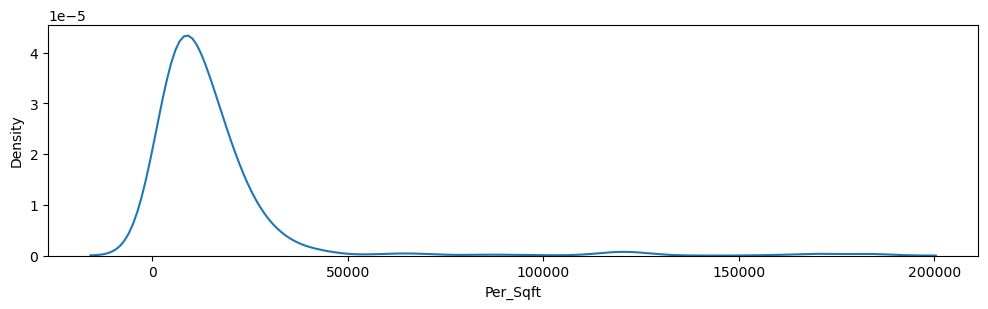

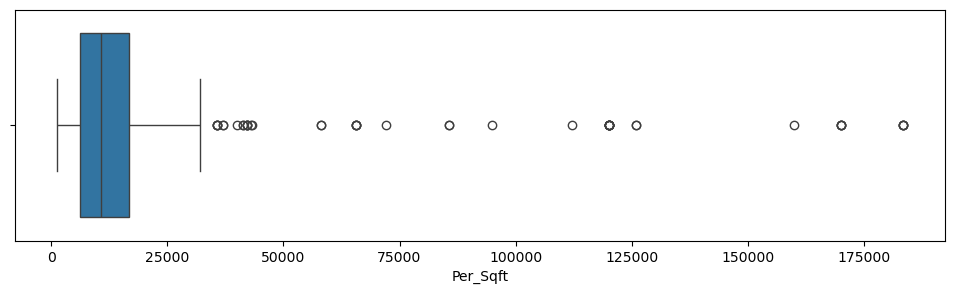

____________________________________________________________________________________________________
after imputing null values with mean


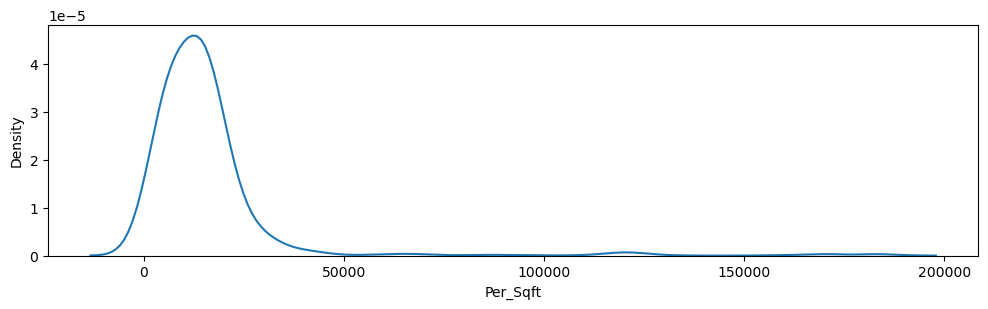

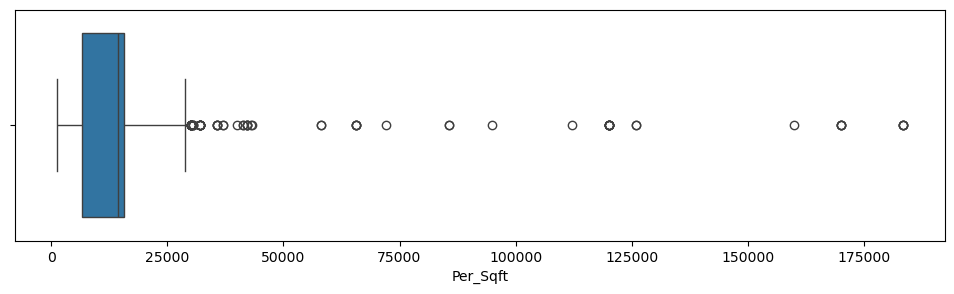

In [15]:
print('before imputing null values with mean')
plt.figure(figsize=(12,3))
sns.kdeplot(df['Per_Sqft'])
plt.show()
plt.figure(figsize=(12,3))
sns.boxplot(x=df['Per_Sqft'])
plt.show()
print('_'*100)
df['Per_Sqft'].fillna(df['Per_Sqft'].fillna(df['Per_Sqft'].mean()))
print('after imputing null values with mean')
plt.figure(figsize=(12,3))
sns.kdeplot(df['Per_Sqft'].fillna(df['Per_Sqft'].mean()))
plt.show()
plt.figure(figsize=(12,3))
sns.boxplot(x=df['Per_Sqft'].fillna(df['Per_Sqft'].mean()))
plt.show()


In [16]:
#950--->12500000
#1----->12500000/950
df.Per_Sqft.fillna(df.Price/df.Area,inplace=True)

In [17]:
df.isnull().sum()[df.isnull().sum()>0]

Bathroom     1
Parking     30
Type         5
dtype: int64

In [ ]:
#parking
plt.figure(figsize=(12,3))
sns.boxplot(x=df['Parking'])
plt.show()
plt.figure(figsize=(12,3))
sns.countplot(x=df.Parking)
plt.show()

In [18]:
df[df.Parking>100]

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
252,1100.0,2,2.0,Semi-Furnished,Vasundhara,East Delhi,Vasundhara Enclave,114.0,Ready_to_move,Resale,Apartment,9090.909091,10000000
902,900.0,2,2.0,Unfurnished,Vasundhara,East Delhi,"Mangal Apartment, Vasundhara Enclave",114.0,Ready_to_move,Resale,Apartment,10000.000000,9000000
906,950.0,2,2.0,Unfurnished,Vasundhara,East Delhi,Vasundhara Enclave,114.0,Ready_to_move,Resale,Apartment,8526.315789,8100000


In [19]:
df.Parking.replace(114,1,inplace=True)

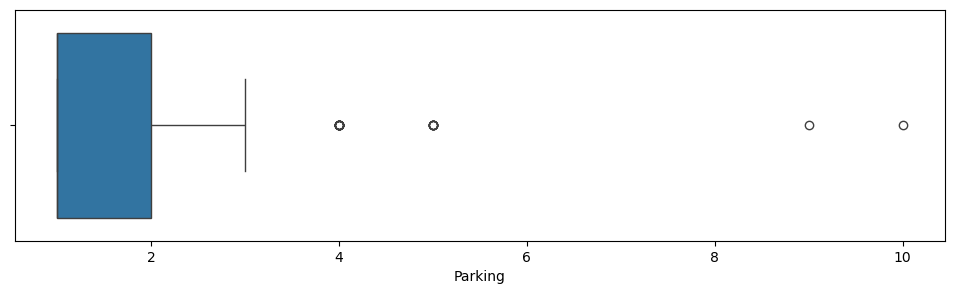

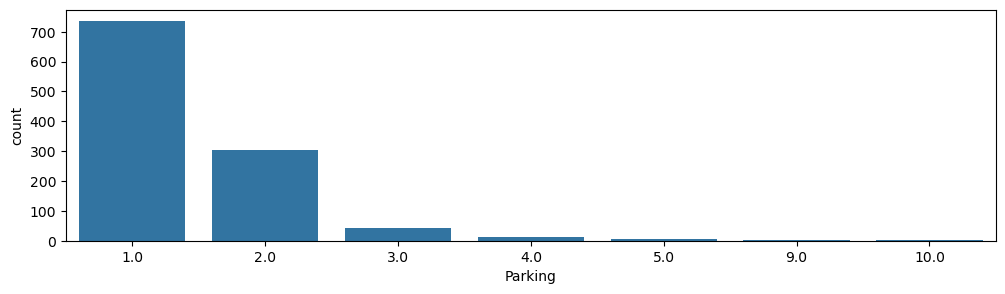

In [20]:
plt.figure(figsize=(12,3))
sns.boxplot(x=df['Parking'])
plt.show()
plt.figure(figsize=(12,3))
sns.countplot(x=df.Parking)
plt.show()

In [21]:
df.Parking.isnull().sum()

np.int64(30)

In [22]:
df.Parking.fillna(df.Parking.median(),inplace=True)

In [23]:
df.Parking.isnull().sum()

np.int64(0)

In [24]:
#outliers
df.Parking.value_counts()

Parking
1.0     767
2.0     304
3.0      41
4.0      14
5.0       7
9.0       1
10.0      1
Name: count, dtype: int64

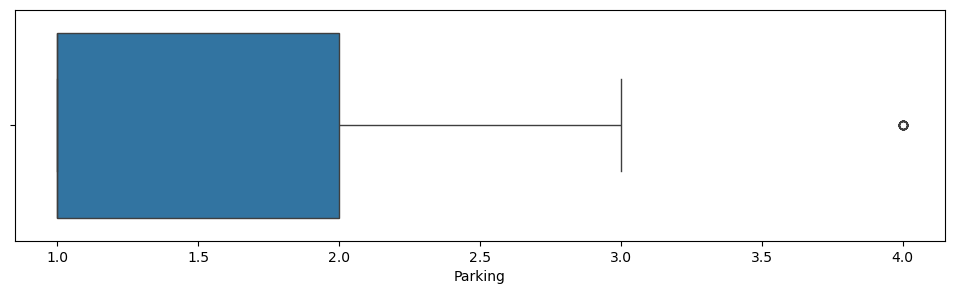

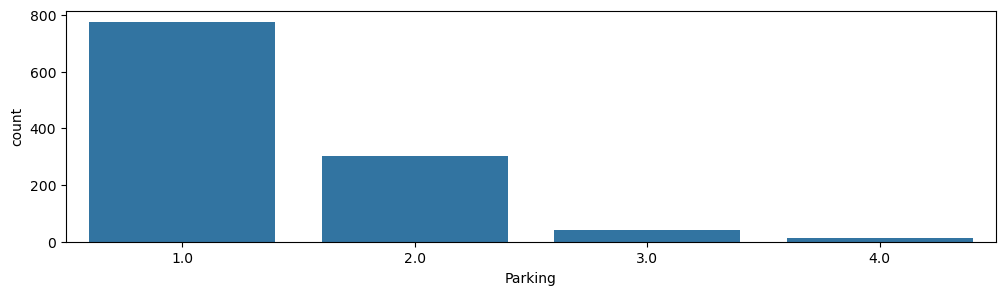

In [25]:
df[df.Parking>4]
df.Parking=np.where(df.Parking>4,1,df.Parking)
plt.figure(figsize=(12,3))
sns.boxplot(x=df['Parking'])
plt.show()
plt.figure(figsize=(12,3))
sns.countplot(x=df.Parking)
plt.show()

In [26]:
df.Parking=df.Parking.astype(int)

In [27]:
df.isnull().sum()[df.isnull().sum()>0]

Bathroom    1
Type        5
dtype: int64

In [28]:
#dropping null values
df.dropna(inplace=True)

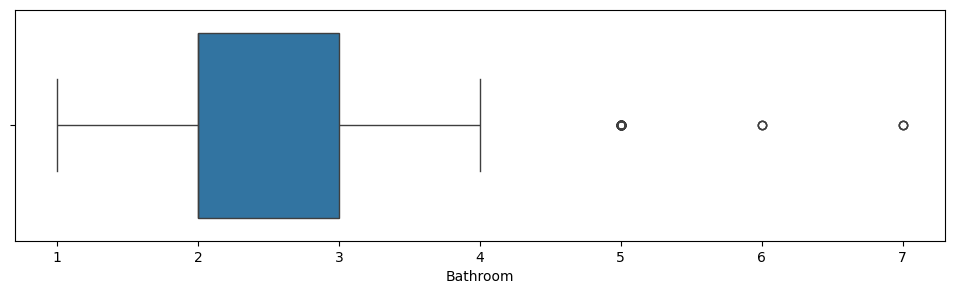

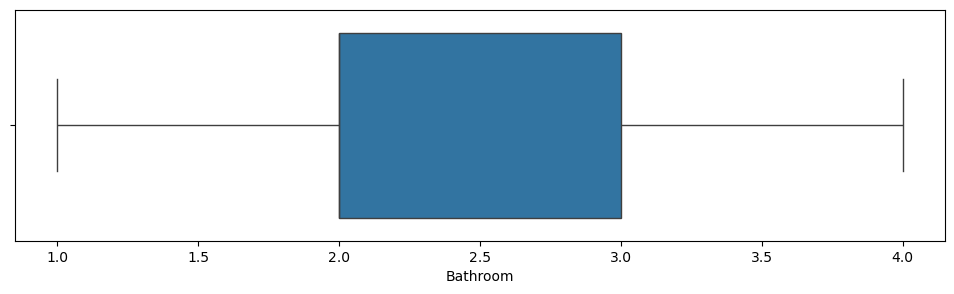

In [29]:
plt.figure(figsize=(12,3))
sns.boxplot(x=df.Bathroom)
plt.show()
df.Bathroom.clip(upper=4,inplace=True)
plt.figure(figsize=(12,3))
sns.boxplot(x=df.Bathroom)
plt.show()

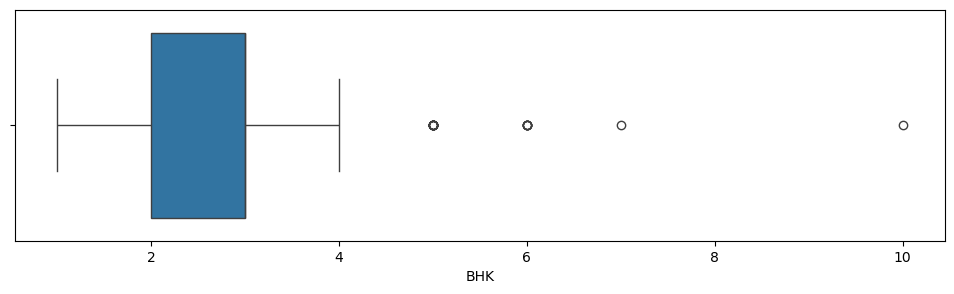

In [30]:
plt.figure(figsize=(12,3))
sns.boxplot(x=df.BHK)
plt.show()

In [31]:
df[df.BHK>5]
df.BHK=np.where(df.BHK>4,3,df.BHK)
# df.Area<900

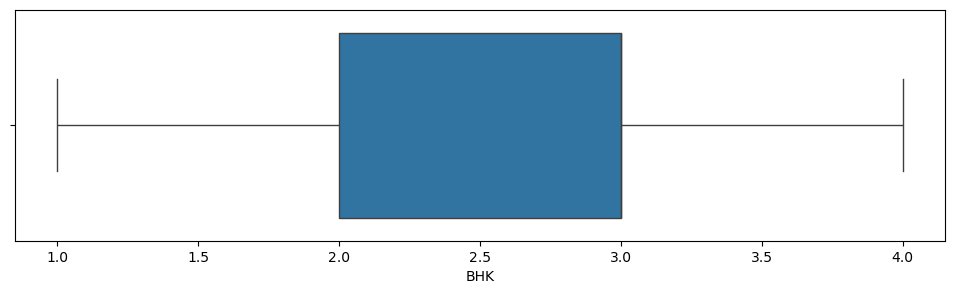

In [32]:
plt.figure(figsize=(12,3))
sns.boxplot(x=df.BHK)
plt.show()

In [33]:
df.Bathroom=df.Bathroom.astype(int)

In [34]:
df.Locality.str.split(',',expand=True).iloc[:,0:1].value_counts().head(10) #drop

0                     
Lajpat Nagar 3            32
Kailash Colony            30
Yamuna Vihar              29
Lajpat Nagar 2            29
J R Designers Floors      28
Chittaranjan Park         24
Mehrauli                  24
Laxmi Nagar               23
DDA Flats Sarita Vihar    22
Saket                     21
Name: count, dtype: int64

In [35]:
print(df.District.value_counts().index)
print(len(df.District.value_counts().index))

Index(['South Delhi', 'West Delhi', 'East Delhi', 'North West Delhi',
       'South West Delhi', 'South West Delhi ', 'Shahdara', 'South East Delhi',
       'Central Delhi'],
      dtype='object', name='District')
9


In [36]:
df.District=df.District.str.strip()

In [37]:
print(df.District.value_counts().index)
print(len(df.District.value_counts().index))

Index(['South Delhi', 'South West Delhi', 'West Delhi', 'East Delhi',
       'North West Delhi', 'Shahdara', 'South East Delhi', 'Central Delhi'],
      dtype='object', name='District')
8


In [38]:
#preprocessing done

In [39]:
#EXPLORATORY ANALYSIS
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Location', 'District',
       'Locality', 'Parking', 'Status', 'Transaction', 'Type', 'Per_Sqft',
       'Price'],
      dtype='object')

In [40]:
#univariate analysis
#2-2 graph
#1 column-->analysis

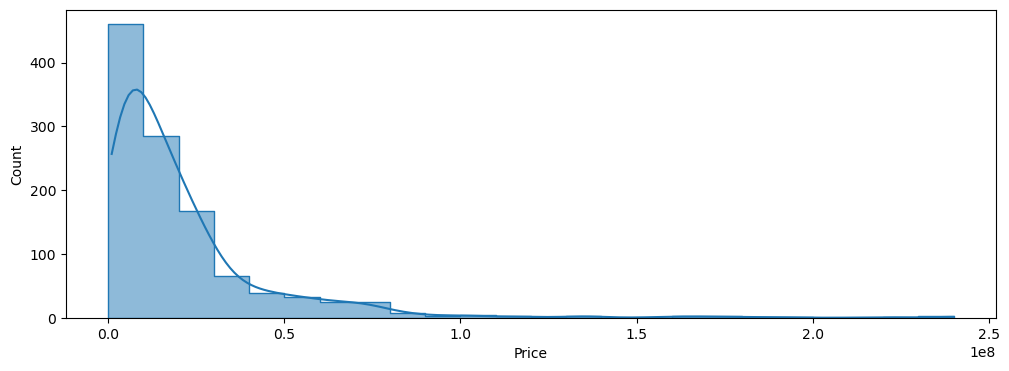

<Figure size 1200x400 with 0 Axes>

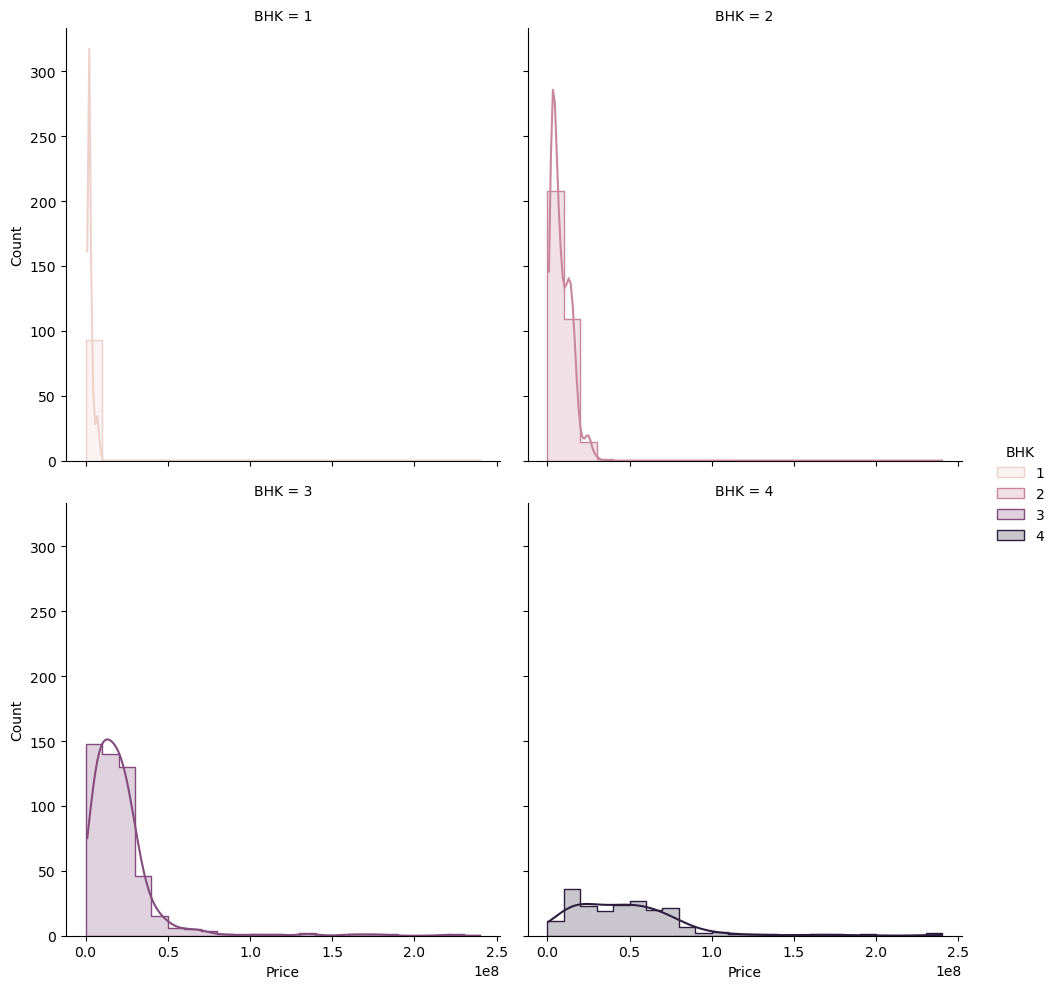

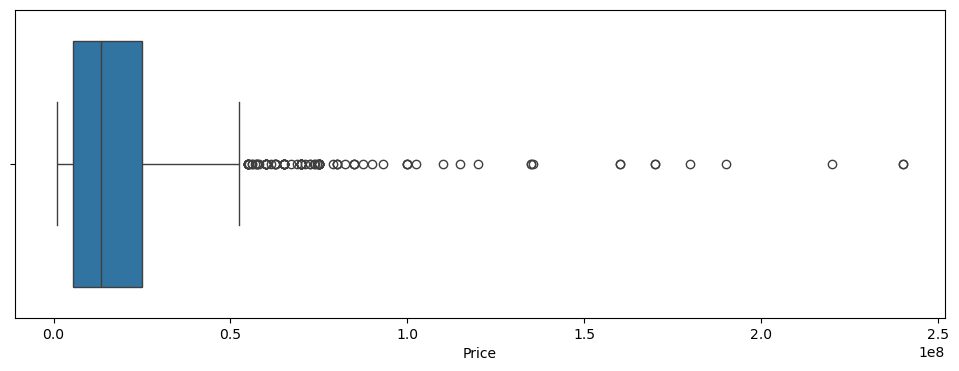

In [41]:
#price
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='Price',bins=range(0,250000000,10000000),kde=True,element='step')
plt.show()
plt.figure(figsize=(12,4))
sns.displot(data=df,x='Price',hue='BHK',col='BHK',col_wrap=2,bins=range(0,250000000,10000000),kde=True,element='step')
plt.show()
plt.figure(figsize=(12,4))
sns.boxplot(data=df,x='Price')
plt.show()

* Price distribution is right-skewed, meaning most properties are priced below ₹5 Cr, with fewer high-value properties extending the upper tail.

* Boxplot shows most outliers above ₹5 Cr, representing premium properties and a natural real estate pattern.

* 1 BHK: All listings are below ₹1 Cr, indicating an affordable segment.

* 2 BHK: Majority of listings are below ₹3 Cr, forming a mid-range cluster.

* 3 BHK: Highest number of listings with prices extending up to ₹10 Cr, covering both mid and premium segments.

* 4 BHK: Fewer listings with a long tail reaching up to ₹24 Cr, indicating luxury properties.

* Overall, with increase in BHK, price spread and variability also increase.


In [42]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Location', 'District',
       'Locality', 'Parking', 'Status', 'Transaction', 'Type', 'Per_Sqft',
       'Price'],
      dtype='object')

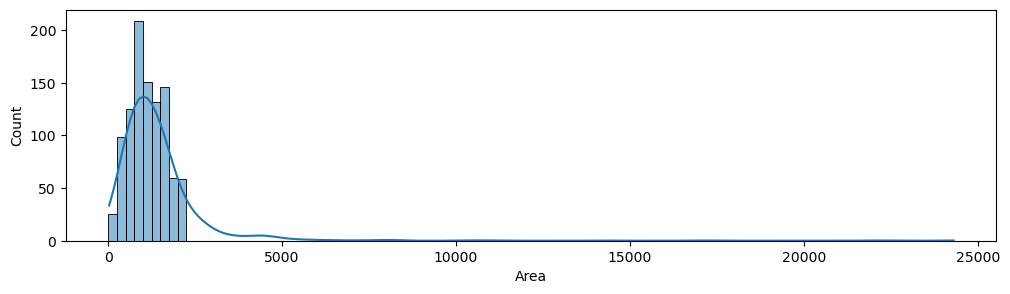

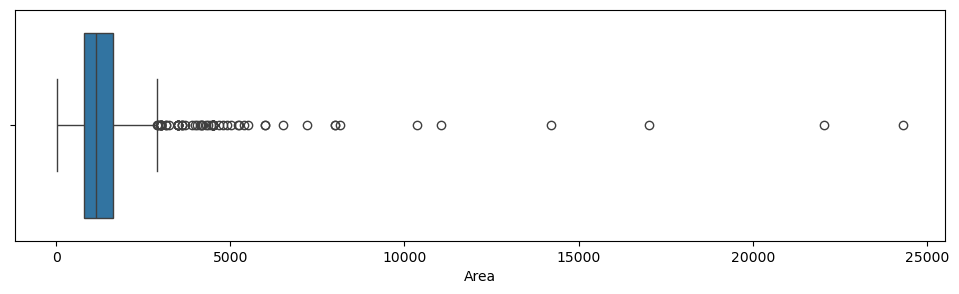

In [43]:
df.Area
plt.figure(figsize=(12,3))
sns.histplot(data=df,x='Area',bins=range(0,2500,250),kde=True)
plt.show()
plt.figure(figsize=(12,3))
sns.boxplot(data=df,x='Area')#bins=range(0,2500,250),kde=True)
plt.show()


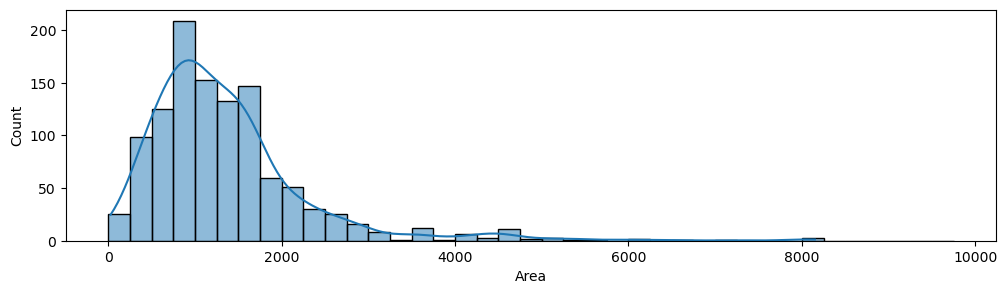

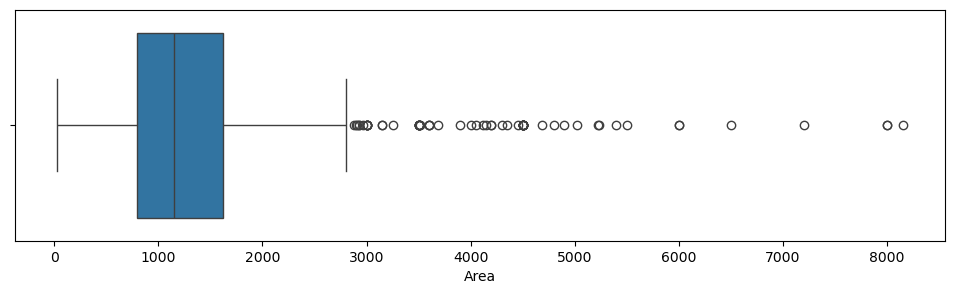

In [44]:
df[df.Area>10000]
df.Area=np.where(df.Area>10000,df.Area/10,df.Area)
df.Area
plt.figure(figsize=(12,3))
sns.histplot(data=df,x='Area',bins=range(0,10000,250),kde=True)
plt.show()
plt.figure(figsize=(12,3))
sns.boxplot(data=df,x='Area')#bins=range(0,10000,250),kde=True)
plt.ylabel('')
plt.show()


* Areas above **10,000 sq ft were capped/adjusted** to reduce extreme variation, as they were disproportionately affecting the relationship between **area and price per sq ft**.

* These very large properties are rare and behave differently (luxury segment), so treating them helps in achieving a more stable analysis.

* The distribution remains **right-skewed**, indicating that most properties fall in the **lower area range**, with fewer large-sized properties extending the tail.

* This suggests that **majority of listings require relatively smaller area**, while high-area properties are limited and contribute to skewness.


* Areas above **10,000 sq ft were capped/adjusted** to reduce extreme variation, as they were disproportionately affecting the relationship between **area and price per sq ft**.

* These very large properties are rare and behave differently (luxury segment), so treating them helps in achieving a more stable analysis.

* The distribution remains **right-skewed**, indicating that most properties fall in the **lower area range**, with fewer large-sized properties extending the tail.

* This suggests that **majority of listings require relatively smaller area**, while high-area properties are limited and contribute to skewness.


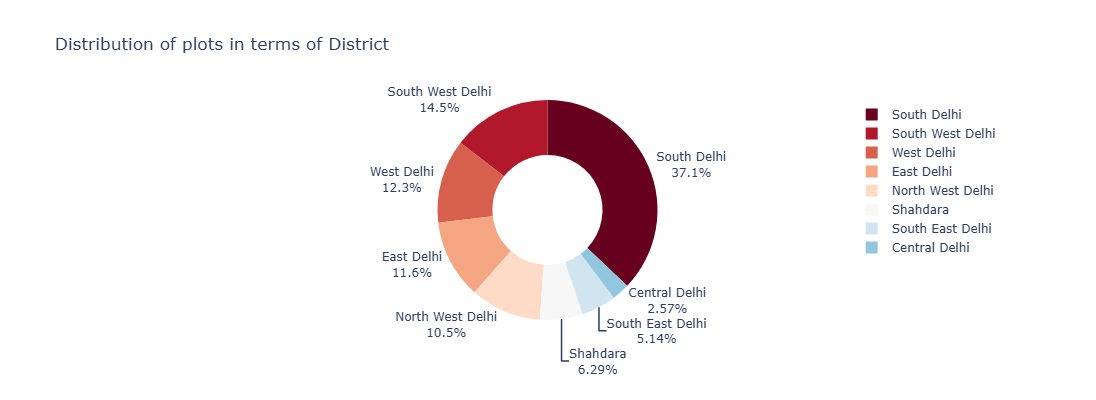

In [52]:
df.columns
import plotly
temp=df.District.value_counts().reset_index()
#px.pie(values)
px.pie(temp,values='count',names='District',hole=0.5,color_discrete_sequence=plotly.colors.sequential.RdBu,height=400,title='Distribution of plots in terms of District').update_traces(textposition='outside',textinfo='percent+label')

* Majority of listings are concentrated in **South Delhi (~37%)**, indicating high supply and active real estate transactions in this region. This is likely due to:

  * Presence of **premium and well-developed localities**
  * Higher demand from affluent buyers
  * More builder floors and resale activity

* **Central Delhi (~2.5%) has the least listings**, which can be attributed to:

  * Limited residential inventory (more **commercial and government zones**)
  * Strict regulations and fewer new developments
  * High property value leading to **lower transaction frequency**

* Overall, listing distribution reflects **urban structure**, where residential expansion is higher in outer/south regions compared to centrally restricted zones.


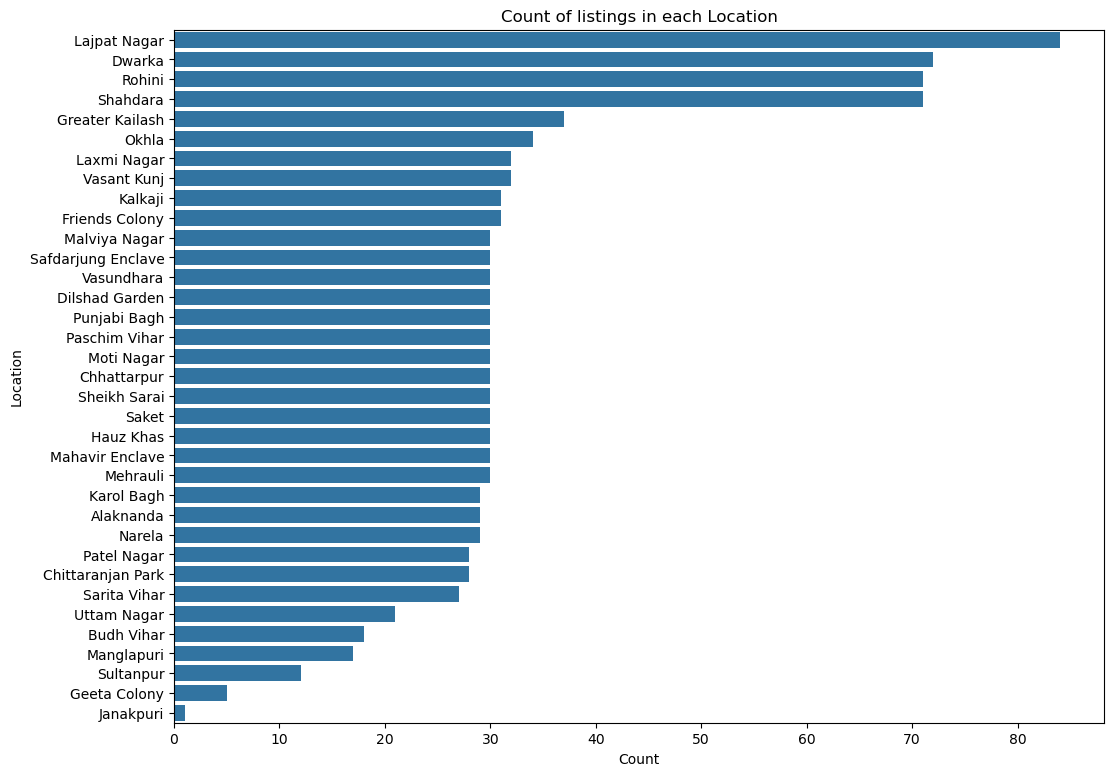

In [46]:
#location
loc_temp=df.Location.value_counts().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,9))
sns.countplot(data=df,y='Location',order=loc_temp.Location)
plt.title('Count of listings in each Location')
plt.ylabel('Location')
plt.xlabel('Count')
plt.show()

* Locations like **Lajpat Nagar, Dwarka, Rohini, and Shahdara** have the highest listings, indicating **high competition and saturated markets**.

* Areas such as **Janakpuri, Geeta Colony, Sultanpur, Manglapuri, and Budh Vihar** show **low listing counts**, suggesting **untapped or less competitive markets**.

* These low-listing regions can be considered **potential business opportunities**, as:

  * Competition is lower
  * Scope for new supply or listings is higher
  * Early entry can provide a market advantage

* However, low listings may also indicate:

  * Lower demand
  * Infrastructure or location constraints

* Hence, these regions should be evaluated further by combining **price trends, demand, and connectivity** before finalizing business decisions.


In [47]:
#multivariate analysis
df.corr(numeric_only=True)

,Area,BHK,Bathroom,Parking,Per_Sqft,Price
Area,1.000000,0.617095,0.705677,0.343375,0.260443,0.841547
BHK,0.617095,1.000000,0.777647,0.269857,0.178404,0.523527
Bathroom,0.705677,0.777647,1.000000,0.335330,0.222332,0.659712
Parking,0.343375,0.269857,0.335330,1.000000,0.162736,0.371117
Per_Sqft,0.260443,0.178404,0.222332,0.162736,1.000000,0.343487
Price,0.841547,0.523527,0.659712,0.371117,0.343487,1.000000


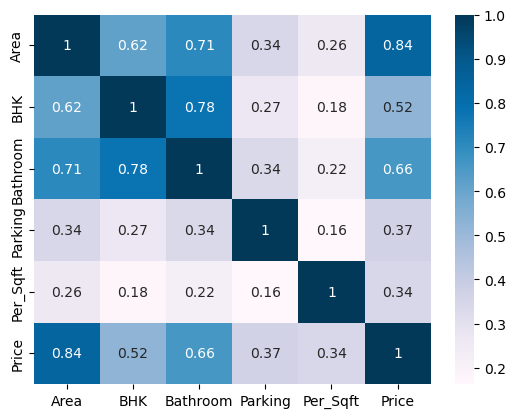

In [48]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='PuBu')
plt.show()

* **Area and Price** show strong correlation (~0.84), indicating that larger properties tend to have higher prices.

* **BHK, Bathroom, and Area** are highly correlated with each other (0.6–0.78), suggesting **multicollinearity**, as these features represent similar property size characteristics.

* **Bathroom** also has a strong relationship with **Price (~0.66)**, reinforcing that larger homes (with more bathrooms) are priced higher.

* **Per Sqft** has weak correlation with most variables, indicating it behaves more like an **independent pricing metric** rather than being driven by size or configuration.

* **Parking** also shows low correlation with other features, suggesting it has **limited direct impact on price or size-related variables** in this dataset.

* Overall, **size-related features (Area, BHK, Bathroom)** are interdependent, while **Per Sqft and Parking** contribute less to linear relationships.


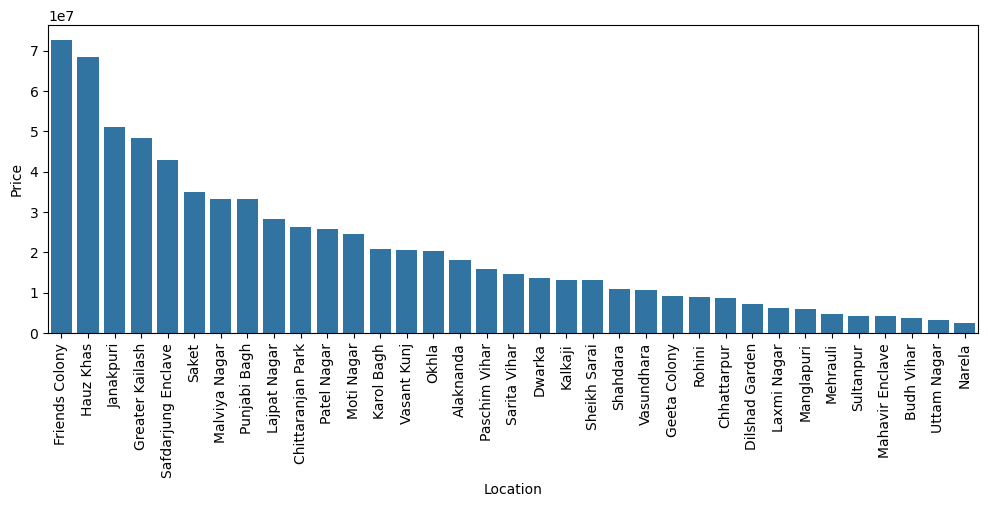

In [53]:
#bivariate analysis
#location'
#price
loc_temp_price=df.groupby('Location')['Price'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,4))
sns.barplot(data=df,x='Location',y='Price',ci=False,order=loc_temp_price.Location)
plt.xticks(rotation=90)
plt.show()


* **High Budget Locations**:

  * Areas like **Friends Colony, Hauz Khas, Lajpat Nagar, Greater Kailash, Safdarjung Enclave** show the highest average prices.
  * These locations cater to **premium and luxury buyers** with high purchasing capacity.

* **Mid Budget Locations**:

  * Areas such as **Saket, Malviya Nagar, Rajouri Garden, Lajpat Nagar, Patel Nagar, Vasant Kunj** fall in the mid-price range.
  * Suitable for **upper-middle and mid-income buyers**.

* **Low Budget Locations**:

  * Locations like **Uttam Nagar, Narela, Budh Vihar, Mahavir Enclave, Sultanpur** have relatively lower prices.
  * Target segment includes **budget-conscious buyers and first-time homeowners**.

* **Overall Insight**:

  * Price distribution across locations helps in **clear customer segmentation**, enabling targeted marketing strategies based on affordability levels.


In [54]:
df.columns
#bivariate analysis

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Location', 'District',
       'Locality', 'Parking', 'Status', 'Transaction', 'Type', 'Per_Sqft',
       'Price'],
      dtype='object')

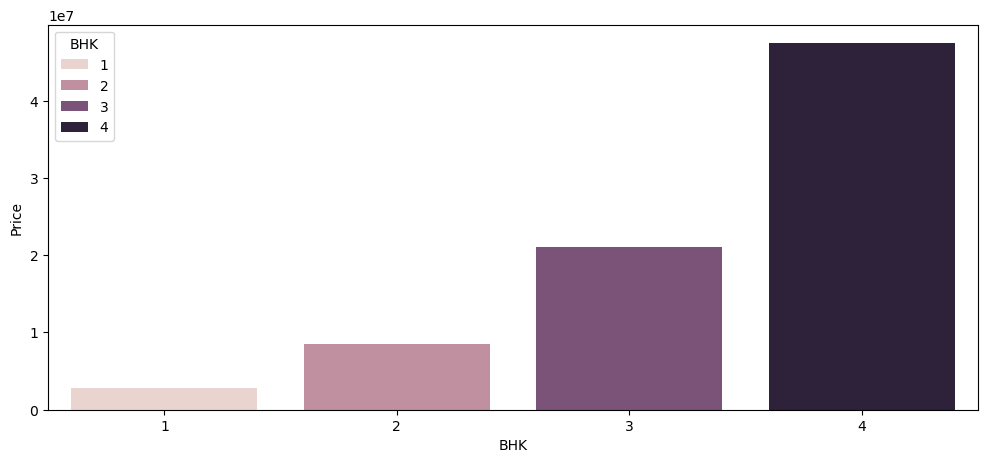

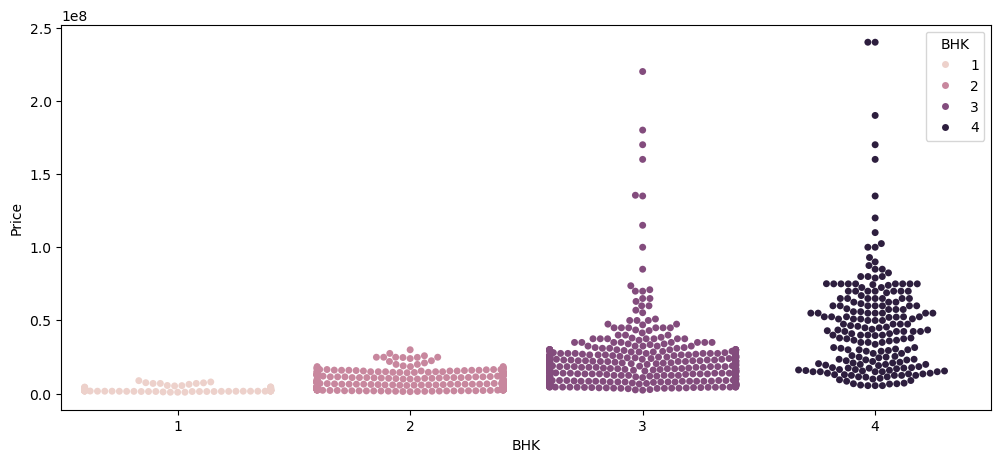

In [57]:
plt.figure(figsize=(12,5))
sns.barplot(data=df,x='BHK',y='Price',hue='BHK',ci=False)
plt.show()
plt.figure(figsize=(12,5))
sns.swarmplot(data=df,x='BHK',y='Price',hue='BHK')
plt.show()

* The price distribution indicates a clear upward trend with increasing BHK size, where **3 BHK and 4 BHK properties dominate the higher price range**.
* Although there is some overlap in the price spread of 3 BHK and 4 BHK units, the **average price of 4 BHK properties is noticeably higher**, suggesting premium positioning and larger area offerings.
* In contrast, **1 BHK and 2 BHK units are significantly lower in price**, making them more accessible and budget-friendly segments.
* The wider spread in 3 BHK and 4 BHK prices also indicates **greater variability**, likely due to factors such as location, amenities, and property size.


In [1]:
df.columns
plt.figure(figsize=(12,5))
sns.scatterplot(data=df,x='Area',y='Price')
plt.show()
plt.figure(figsize=(12,5))
sns.histplot(data=df,x='Area',y='Price')
plt.show()

NameError: name 'df' is not defined

##  **Area vs Price**

* There is a **positive correlation** → as area increases, price also increases.
* A **high-density cluster** in the mid-area range shows most properties are listed there.
* Price variation **increases with larger areas**, indicating influence of other factors like location and amenities.
* Few **high-area, high-price outliers** represent premium/luxury properties.


In [59]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Location', 'District',
       'Locality', 'Parking', 'Status', 'Transaction', 'Type', 'Per_Sqft',
       'Price'],
      dtype='object')

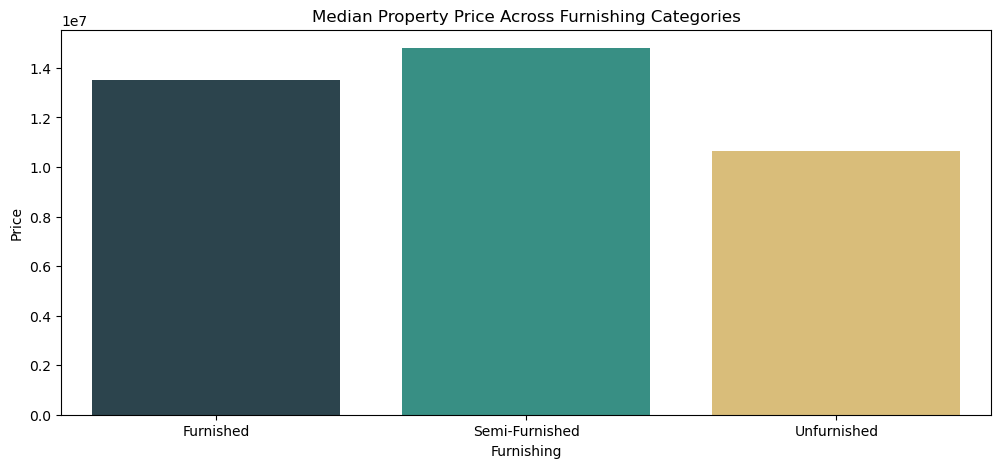

In [72]:
plt.figure(figsize=(12,5))
colors=["#264653", "#2A9D8F", "#E9C46A"]
sns.barplot(data=df,x='Furnishing',y='Price',ci=False,hue='Furnishing',estimator='median',palette=colors)
plt.title("Median Property Price Across Furnishing Categories")
plt.show()

## **Furnishing vs Price Analysis**

### Key Insights

* **Semi-furnished properties have the highest median price**, indicating strong demand in this segment.
* **Furnished properties are slightly less expensive**, but still fall in the premium category.
* **Unfurnished properties are significantly cheaper**, making them the most budget-friendly option.

---

### Interpretation

* Buyers may prefer **semi-furnished homes** as they offer a balance between cost and convenience.
* Fully furnished homes may include higher upfront costs but are **not always the most expensive**.
* Unfurnished homes attract **price-sensitive buyers or investors**.


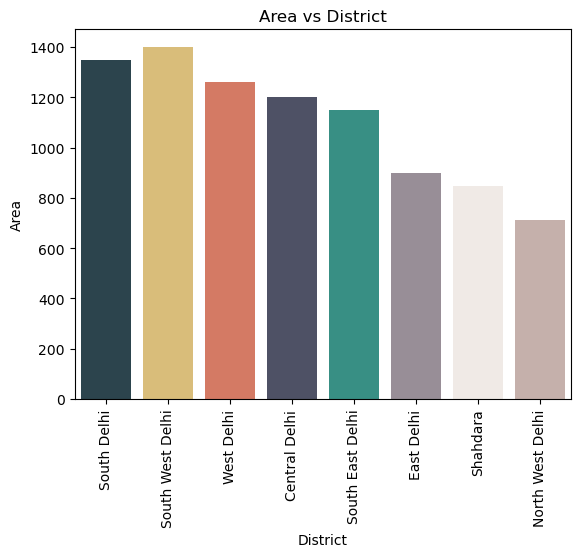

           District         Area
0       South Delhi  1653.151593
1  South West Delhi  1412.335366
2        West Delhi  1405.888324
3     Central Delhi  1356.896552
4  South East Delhi  1169.310345
5        East Delhi   968.238271
6          Shahdara   962.744731
7  North West Delhi   886.398114


In [75]:
temp_district_area=df.groupby('District')['Area'].mean().sort_values(ascending=False).reset_index()
colors = ["#4A4E69", "#9A8C98", "#C9ADA7", "#F2E9E4",
          "#264653", "#2A9D8F", "#E9C46A", "#E76F51"]
sns.barplot(data=df,x='District',y='Area',order=temp_district_area.District,ci=False,estimator='median',hue='District',palette=colors)
plt.xticks(rotation=90)
plt.title('Area vs District')
plt.show()
print(temp_district_area)

## **Area vs District **

* **South West & South Delhi have the largest properties** → premium segments.
* **Central & South East Delhi have moderate-sized homes** → mid-range market.
* **East Delhi, Shahdara & North West Delhi have smaller properties** → affordable/high-density areas.
* Area varies significantly by location → **district strongly impacts property size**.

## 1. Market Overview

* The price distribution is **right-skewed**, indicating that most properties fall within the affordable to mid-range, while a limited number of luxury properties form the upper tail.
* The market exhibits clear segmentation into **budget, mid-range, and premium categories**.

---

## 2. Key Determinants of Price

* **Area** shows a strong positive correlation with price (~0.84), making it the most significant pricing factor.
* **BHK and Bathroom** are highly correlated with area, indicating **multicollinearity** among size-related features.
* **Per Sqft and Parking** demonstrate weak correlations, suggesting limited direct influence on pricing.

---

## 3. Property Configuration Insights

* **1 BHK and 2 BHK** properties belong to the **affordable segment**, with relatively lower price ranges.
* **3 BHK** properties dominate the dataset and span both **mid and premium segments**.
* **4 BHK** properties represent the **luxury segment**, with high variability and extreme price values.
* Price variability increases with property size, reflecting the influence of additional factors such as location and amenities.

---

## 4. Area Analysis

* Most properties are concentrated in the **mid-area range**, indicating strong demand in this segment.
* The distribution is **right-skewed**, with a small number of large properties contributing to the upper tail.
* Extreme values (above 10,000 sq ft) were treated to improve analytical stability.
* Larger properties exhibit higher price variability, highlighting the role of premium features.

---

## 5. Location and District Insights

* **South Delhi** accounts for the highest proportion of listings (~37%), reflecting strong demand and market activity.
* **Central Delhi** has minimal listings (~2.5%), likely due to regulatory constraints and limited residential supply.
* High-listing locations (e.g., Dwarka, Rohini) indicate **competitive and saturated markets**.
* Low-listing locations present **potential opportunities**, though further validation is required.

### District-Level Observations

* **South West and South Delhi** offer larger properties, indicating premium residential zones.
* **Central and South East Delhi** represent mid-sized housing markets.
* **East Delhi, Shahdara, and North West Delhi** are characterized by smaller, more affordable housing units.

---

## 6. Furnishing Impact

* **Semi-furnished properties** have the highest median prices, indicating strong market preference.
* **Furnished properties** remain in the premium category but are slightly lower in price.
* **Unfurnished properties** are the most affordable, catering to budget-conscious buyers.
* Overall, furnishing has a **moderate impact** compared to size and location.

---

## 7. Correlation Insights

* Strong relationships exist among **Area, BHK, and Bathroom**, confirming redundancy in size-related features.
* Weak relationships for **Per Sqft and Parking** suggest they behave as independent or secondary variables.

---

# 🚀 Recommendations

## 1. Business Strategy

* Focus on the **3 BHK segment**, which offers the highest market activity and revenue potential.
* Target customers based on segmentation:

  * **Premium Buyers** → South Delhi, South West Delhi
  * **Mid-Segment Buyers** → Central and South East Delhi
  * **Budget Buyers** → East Delhi, Shahdara

---

## 2. Investment Opportunities

* Explore **low-listing regions** for potential market entry and expansion.
* Validate opportunities using:

  * Demand patterns
  * Infrastructure development
  * Connectivity

---

## 3. Pricing Strategy

* Prioritize **Area and Location** as key pricing drivers.
* Use furnishing and amenities as **secondary differentiators**.

---

## 4. Machine Learning Considerations

* Address **multicollinearity** by removing or combining highly correlated features.
* Handle outliers carefully, especially in the luxury segment.
* Apply feature engineering techniques such as:

  * Price per square foot
  * Location-based encoding

---

## 5. Final Conclusion

* The real estate market is primarily driven by **property size and location**, with furnishing and amenities playing a supporting role.
* Clear segmentation across price and property types enables **data-driven decision-making, targeted marketing, and optimized investment strategies**.


